In [1]:
import pandas as pd
from pathlib import Path
import os
import re # Import the regular expression library

# --- Make sure our custom modules are on the Python path ---
# This allows us to import from 'common' and 'agents'
import sys
# Assuming this notebook is in the project root, this adds the root to the path
if Path.cwd().name == 'DeepRL-MsPacman':
    sys.path.append(str(Path.cwd()))
else:
    # If notebook is elsewhere, you might need to adjust this path
    # For now, let's assume it's in the root
    pass

from common.utils import load_config
from evaluate import evaluate_agent

print("--- Setup Complete ---")

--- Setup Complete ---


In [2]:
# Cell 2: Select the Experiment to Analyze

# --- 1. CONFIGURATION ---

# Specify the agent type we are evaluating
AGENT_TYPE = "dqn" 

# Specify the unique folder name for the experimental run
# Replace this with the actual name of one of your run folders
RUN_FOLDER_NAME = "DQN_Run_1" 

# Define the path to the project's root on your local machine
# This assumes your 'models' folder is in the same directory as the notebook
PROJECT_ROOT = Path.cwd() 
CHECKPOINTS_PATH = PROJECT_ROOT / "models" / f"{AGENT_TYPE}_checkpoints" / RUN_FOLDER_NAME

# Path to a generic config file needed to build the agent object
CONFIG_PATH = PROJECT_ROOT / f"configs/{AGENT_TYPE}_config.yaml" 

# Evaluation parameters
NUM_EVAL_GAMES = 5 # Use a small number for a fast test run

print(f"Agent Type: {AGENT_TYPE}")
print(f"Run Folder: {RUN_FOLDER_NAME}")
print(f"Checkpoints Path: {CHECKPOINTS_PATH}")
print(f"Config File: {CONFIG_PATH}")
print(f"Number of Games per Checkpoint: {NUM_EVAL_GAMES}")

Agent Type: dqn
Run Folder: DQN_Run_1
Checkpoints Path: g:\Github\DeepRL-MsPacman\models\dqn_checkpoints\DQN_Run_1
Config File: g:\Github\DeepRL-MsPacman\configs\dqn_config.yaml
Number of Games per Checkpoint: 5


In [3]:
# Cell 3: Run the Batch Evaluation

# Find all the .pth files in the checkpoint directory
# .glob('*.pth') finds all files ending with .pth
# sorted() ensures we process them in order of timestep
checkpoint_files = sorted(CHECKPOINTS_PATH.glob("*.pth"))

# A list to store the final summary dictionary from each checkpoint
all_summaries = []

all_raw_results = []

print(f"\nFound {len(checkpoint_files)} checkpoints to evaluate for run: {RUN_FOLDER_NAME}")

# --- NEW: Use regex to extract the run number from the folder name ---
run_match = re.search(r'(\d+)$', RUN_FOLDER_NAME) # '$' matches the end of the string
if run_match:
    run_number = int(run_match.group(1))
else:
    run_number = 0 # Default to 0 if no number is found
print(f"Extracted Run Number: {run_number}")

# Loop through each checkpoint file
for model_path in checkpoint_files:
    print(f"\n{'='*20} EVALUATING CHECKPOINT: {model_path.name} {'='*20}")
    
    # --- Use regex to extract the timestep from the filename ---
    match = re.search(r'step_(\d+)\.pth', model_path.name)
    if not match:
        print(f"Could not extract timestep from {model_path.name}. Skipping.")
        continue
    timestep = int(match.group(1))
    
    # --- Load the base config and add evaluation-specific settings ---
    config = load_config(CONFIG_PATH)
    config['agent'] = AGENT_TYPE
    config['model_path'] = str(model_path)
    config['num_games'] = NUM_EVAL_GAMES
    config['enable_reward_shaping'] = False # Always use true score for evaluation

    # --- Run the evaluation for this checkpoint ---
    # evaluate_agent returns (raw_per_game_df, summary_df)
    # We only need the summary for our final table.
    raw_results_df, summary_df = evaluate_agent(config) # summary_df is our one-row DataFrame of results

    # Add the timestep as a new column directly to this DataFrame
    summary_df['timestep'] = timestep
    summary_df['run_number'] = run_number # <-- ADD RUN NUMBER
    all_summaries.append(summary_df)

    # Append the entire one-row DataFrame to our list of results
    raw_results_df['timestep'] = timestep
    raw_results_df['run_number'] = run_number # <-- ADD RUN NUMBER
    all_raw_results.append(raw_results_df)

print("\n\n--- Batch Evaluation Complete ---")


Found 15 checkpoints to evaluate for run: DQN_Run_1
Extracted Run Number: 1

==================== EVALUATING CHECKPOINT: dqn_1_model_step_100000.pth ====================
Using device: cuda


c:\Users\Alex\anaconda3\envs\mspacman_rl\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Environment created and wrapped with unified AtariWrapper.
DQN Agent instantiated.

Model loaded from g:\Github\DeepRL-MsPacman\models\dqn_checkpoints\DQN_Run_1\dqn_1_model_step_100000.pth
Agent loaded from g:\Github\DeepRL-MsPacman\models\dqn_checkpoints\DQN_Run_1\dqn_1_model_step_100000.pth


g:\Github\DeepRL-MsPacman\agents\dqn_agent.py:225: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(path, map_location=self.device)


Evaluation completed. Results for 10 games:
   mean_score  std_score  min_score  Q1_score  Median_score  Q3_score  \
0       102.0  28.982753       60.0      75.0         120.0     120.0   

   max_score  mean_steps  std_steps  level_1_completion_rate  \
0      120.0       528.4  39.609763                      0.0   

   mean_level_reached  max_level_reached  
0                 0.0                  0  

==================== EVALUATING CHECKPOINT: dqn_1_model_step_1000000.pth ====================
Using device: cuda
Environment created and wrapped with unified AtariWrapper.
DQN Agent instantiated.

Model loaded from g:\Github\DeepRL-MsPacman\models\dqn_checkpoints\DQN_Run_1\dqn_1_model_step_1000000.pth
Agent loaded from g:\Github\DeepRL-MsPacman\models\dqn_checkpoints\DQN_Run_1\dqn_1_model_step_1000000.pth


...

Evaluation completed. Results for 10 games:
   mean_score  std_score  min_score  Q1_score  Median_score  Q3_score  \
0       355.0  95.481237      240.0     295.0         340.0     350.0   

   max_score  mean_steps   std_steps  level_1_completion_rate  \
0      540.0       585.8  113.963737                      0.0   

   mean_level_reached  max_level_reached  
0                 0.0                  0  

==================== EVALUATING CHECKPOINT: dqn_model_step_50000.pth ====================
Using device: cuda
Environment created and wrapped with unified AtariWrapper.
DQN Agent instantiated.

Model loaded from g:\Github\DeepRL-MsPacman\models\dqn_checkpoints\DQN_Run_1\dqn_model_step_50000.pth
Agent loaded from g:\Github\DeepRL-MsPacman\models\dqn_checkpoints\DQN_Run_1\dqn_model_step_50000.pth


g:\Github\DeepRL-MsPacman\agents\dqn_agent.py:225: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(path, map_location=self.device)


Evaluation completed. Results for 10 games:
   mean_score  std_score  min_score  Q1_score  Median_score  Q3_score  \
0        70.0        0.0       70.0      70.0          70.0      70.0   

   max_score  mean_steps  std_steps  level_1_completion_rate  \
0       70.0       531.0        0.0                      0.0   

   mean_level_reached  max_level_reached  
0                 0.0                  0  

==================== EVALUATING CHECKPOINT: dqn_model_step_500000.pth ====================
Using device: cuda
Environment created and wrapped with unified AtariWrapper.
DQN Agent instantiated.

Model loaded from g:\Github\DeepRL-MsPacman\models\dqn_checkpoints\DQN_Run_1\dqn_model_step_500000.pth
Agent loaded from g:\Github\DeepRL-MsPacman\models\dqn_checkpoints\DQN_Run_1\dqn_model_step_500000.pth


g:\Github\DeepRL-MsPacman\agents\dqn_agent.py:225: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(path, map_location=self.device)


Evaluation completed. Results for 10 games:
   mean_score   std_score  min_score  Q1_score  Median_score  Q3_score  \
0       502.0  174.279469      380.0     392.5         410.0     567.5   

   max_score  mean_steps   std_steps  level_1_completion_rate  \
0      810.0       640.6  161.800426                      0.0   

   mean_level_reached  max_level_reached  
0                 0.0                  0  


--- Batch Evaluation Complete ---


In [4]:
# Cell 4: Display Aggregated Results

if all_summaries:
    final_results_df = pd.concat(all_summaries, ignore_index=True)
    final_results_df = final_results_df.set_index(['run_number', 'timestep']).sort_index()
    
    # --- NEW: Process Raw Data ---
    # Concatenate all the raw game DataFrames into one big master DataFrame
    all_raw_results_df = pd.concat(all_raw_results, ignore_index=True)

    print("\n--- FINAL AGGREGATED RESULTS ---")
    display(final_results_df)

    print("\n--- First 5 rows of combined raw game data ---")
    display(all_raw_results_df.head())
else:
    print("No results were generated.")


--- FINAL AGGREGATED RESULTS ---


mean_score   std_score  min_score  Q1_score  \
run_number timestep                                                
1          10000           70.0    0.000000       70.0      70.0   
           20000           60.0    0.000000       60.0      60.0   
           30000           60.0    0.000000       60.0      60.0   
           40000           70.0    0.000000       70.0      70.0   
           50000           70.0    0.000000       70.0      70.0   
           100000         102.0   28.982753       60.0      75.0   
           100000         301.0   32.812599      250.0     270.0   
           200000         120.0    0.000000      120.0     120.0   
           300000         601.0    3.162278      600.0     600.0   
           400000         355.0   95.481237      240.0     295.0   
           500000         173.0  117.383512       80.0     110.0   
           500000         502.0  174.279469      380.0     392.5   
           1000000        525.0  296.881944      240.0     345.0   
           5000000       1858.0  908.879652     1030.0    1322.5   
           10000000      2454.0  608.407758     1490.0    1977.5   

                     Median_score  Q3_score  max_score  mean_steps  \
run_number timestep                                                  
1          10000             70.0      70.0       70.0       519.0   
           20000             60.0      60.0       60.0       465.0   
           30000             60.0      60.0       60.0       483.0   
           40000             70.0      70.0       70.0       519.0   
           50000             70.0      70.0       70.0       531.0   
           100000           120.0     120.0      120.0       528.4   
           100000           315.0     330.0      330.0       493.8   
           200000           120.0     120.0      120.0       493.0   
           300000           600.0     600.0      610.0       567.0   
           400000           340.0     350.0      540.0       585.8   
           500000           110.0     252.5      380.0       533.2   
           500000           410.0     567.5      810.0       640.6   
           1000000          420.0     582.5     1060.0       656.4   
           5000000         1505.0    2025.0     4130.0       884.4   
           10000000        2475.0    2940.0     3240.0       834.2   

                      std_steps  level_1_completion_rate  mean_level_reached  \
run_number timestep                                                            
1          10000       0.000000                      0.0                 0.0   
           20000       0.000000                      0.0                 0.0   
           30000       0.000000                      0.0                 0.0   
           40000       0.000000                      0.0                 0.0   
           50000       0.000000                      0.0                 0.0   
           100000     39.609763                      0.0                 0.0   
           100000     53.401623                      0.0                 0.0   
           200000      0.000000                      0.0                 0.0   
           300000      8.640988                      0.0                 0.0   
           400000    113.963737                      0.0                 0.0   
           500000     66.802861                      0.0                 0.0   
           500000    161.800426                      0.0                 0.0   
           1000000   137.327023                      0.0                 0.0   
           5000000   122.717562                      0.0                 0.0   
           10000000  128.893410                      0.0                 0.0   

                     max_level_reached  
run_number timestep                     
1          10000                     0  
           20000                     0  
           30000                     0  
           40000                     0  
           50000                     0  
           100000        


--- First 5 rows of combined raw game data ---


,score,steps,max_level,level_1_completed,timestep,run_number
0,120.0,553,0,False,100000,1
1,120.0,553,0,False,100000,1
2,60.0,471,0,False,100000,1
3,120.0,553,0,False,100000,1
4,60.0,471,0,False,100000,1


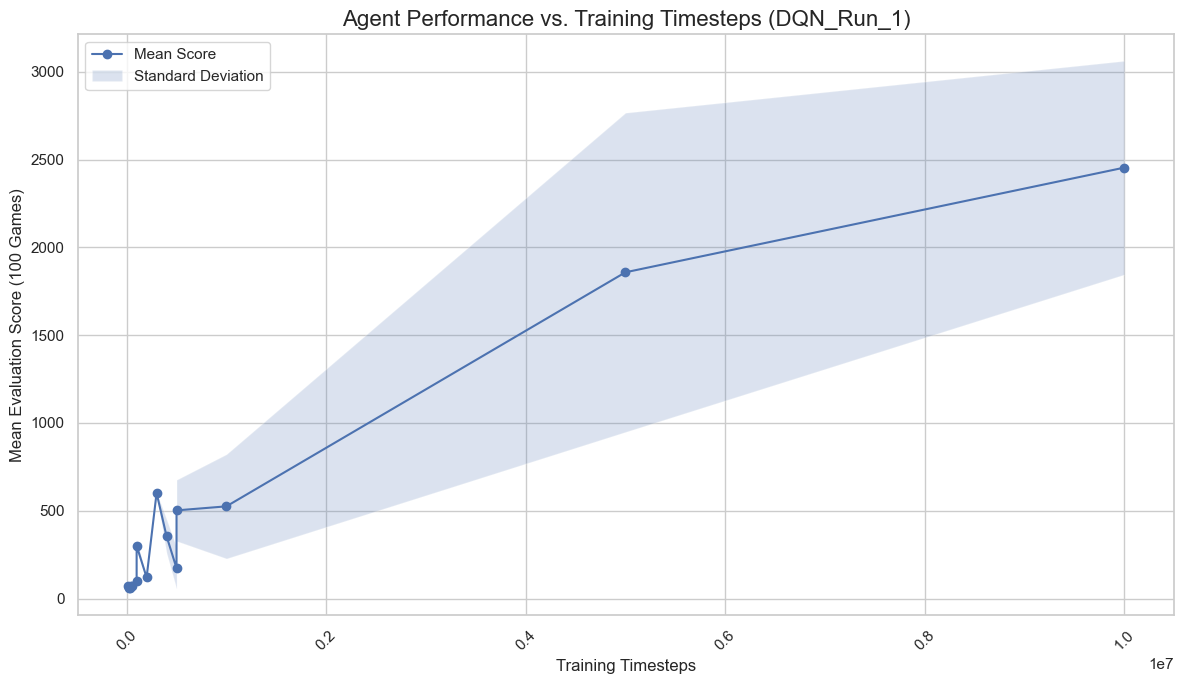

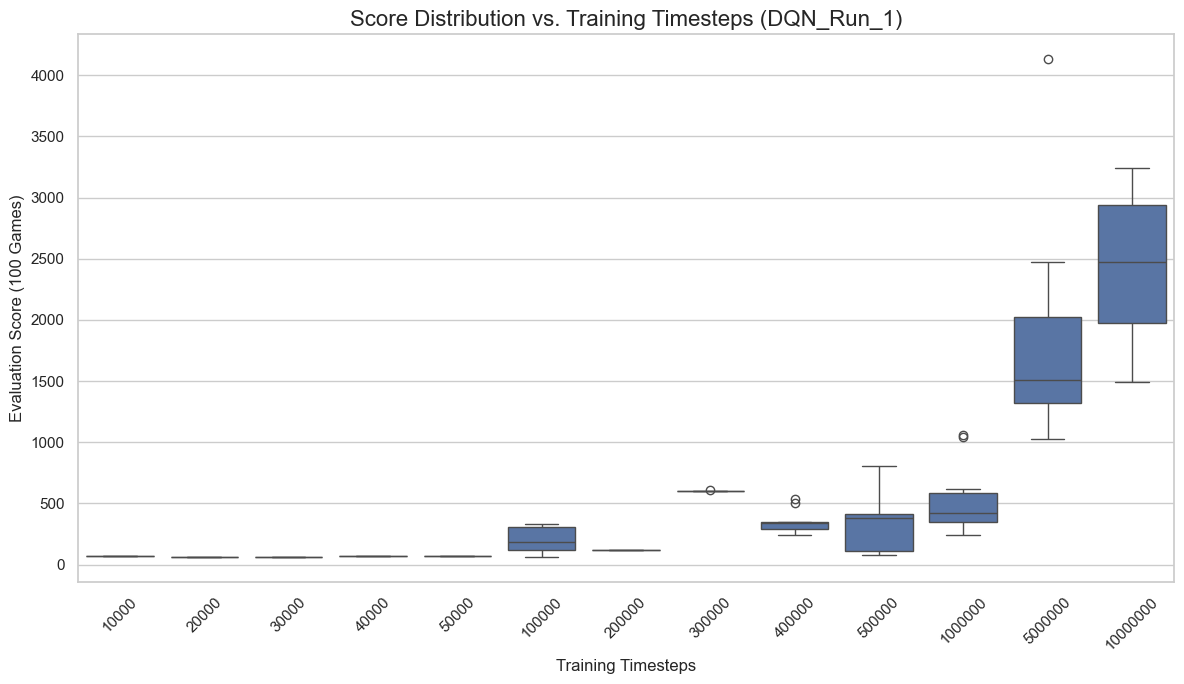

In [6]:
# Cell 5: Visualize the Results

import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style for the plots
sns.set_theme(style="whitegrid")

# Ensure we have results to plot
if not final_results_df.empty:

    # =============================================================================
    # PLOT 1: Mean Score vs. Timesteps with Error Bars (Std Dev)
    # =============================================================================
    
    plt.figure(figsize=(12, 7))
    
    # Get the data for the plot
    timesteps = final_results_df.index.get_level_values('timestep')
    mean_scores = final_results_df['mean_score']
    std_scores = final_results_df['std_score']
    
    # Plot the main line for the mean score
    plt.plot(timesteps, mean_scores, marker='o', linestyle='-', label='Mean Score')
    
    # Add the shaded region for the standard deviation (error bars)
    # This creates a "confidence interval" around our mean score
    plt.fill_between(timesteps, 
                     mean_scores - std_scores, 
                     mean_scores + std_scores, 
                     alpha=0.2, 
                     label='Standard Deviation')
    
    plt.title(f'Agent Performance vs. Training Timesteps ({RUN_FOLDER_NAME})', fontsize=16)
    plt.xlabel('Training Timesteps', fontsize=12)
    plt.ylabel('Mean Evaluation Score (100 Games)', fontsize=12)
    plt.legend()
    plt.grid(True)
    
    # Improve readability of x-axis ticks
    plt.xticks(rotation=45)
    plt.tight_layout() # Adjusts plot to prevent labels from overlapping
    
    plt.show()

    # =============================================================================
    # PLOT 2: Box Plot of Score Distribution vs. Timesteps
    # =============================================================================
    
    plt.figure(figsize=(12, 7))
    
    # Use seaborn's boxplot function
    # x='timestep': The categories on the x-axis will be our checkpoint timesteps.
    # y='score': The values for the box plots will come from the 'score' column.
    # data=all_raw_results_df: The DataFrame containing the data.
    sns.boxplot(x='timestep', y='score', data=all_raw_results_df)
    
    plt.title(f'Score Distribution vs. Training Timesteps ({RUN_FOLDER_NAME})', fontsize=16)
    plt.xlabel('Training Timesteps', fontsize=12)
    plt.ylabel('Evaluation Score (100 Games)', fontsize=12)
    plt.xticks(rotation=45) # Rotate the x-axis labels for better readability
    plt.tight_layout()
    
    plt.show()

else:
    print("No data to plot.")